/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_44977/3089113249.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


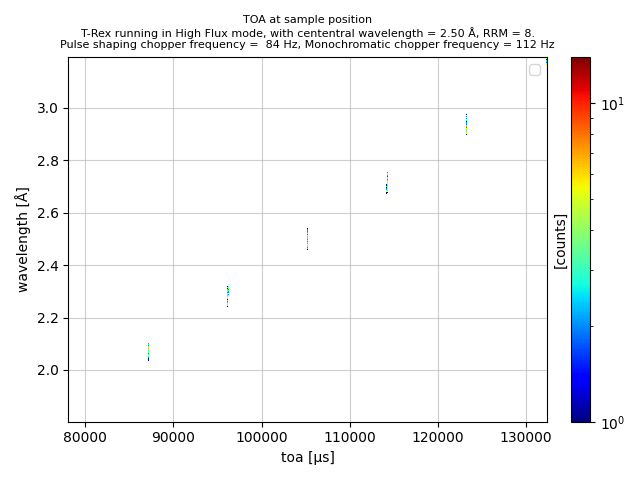

TypeError: only 0-dimensional arrays can be converted to Python scalars

TypeError: only 0-dimensional arrays can be converted to Python scalars

TypeError: only 0-dimensional arrays can be converted to Python scalars

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
import scipp.constants as const



T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8 # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength,rrm=rrm,mode=mode,t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

# Histogram and plot
fig, ax = plt.subplots()
#tof_sample = events_at_sample.hist(wavelength=200, tof=500).plot(norm='log', ax=ax)
toa_sample = events_at_sample.hist(wavelength=800, toa=1500).plot(norm='log', cbar=True, ax=ax, cmap='jet')
ax.set_title('TOA at sample position\n'+str(trex), fontsize=8)



ax.legend()
ax.grid(alpha=0.6)
fig.tight_layout()
plt.show()